# Automated parameter selection for the switching Langevin model

Fits this project's Langevin model, `dz = (a*z + g*z^2) dt + sigma dW`
with an absorbing wall at `z_h = a/g`, against the real grouped lifespan
data in `data/raw/`, using the simulator primitives in `src/`
(`model.simulate_fpt_and_state`, `model.km_from_fpt`) and `data.py` for
loading.

All worms are wild-type until day 10, when each cohort starts receiving
either DMSO (control) or auxin. The data (`data/raw/*.csv`) records each
worm's actual age, not time since treatment started -- there is no
pre-day-10 data, since all three cohorts are identical (untreated) up to
that point.

Two independent single-phase fits, each against its own real data:

- **DMSO_day_10** (single phase): fit `(a0, log_g0, sigma)` directly.
- **Auxin_day_10** (single phase, own parameters): this cohort's own
  independent `(a0_auxin10, log_g0_auxin10)`, fit the same way as DMSO.
  `sigma` is held fixed at the DMSO fit's value, treated as an intrinsic
  property of the organism that the intervention doesn't change.

**Auxin_day_21 is not independently fit.** This cohort received DMSO at
day 10 and was switched onto auxin at day 21 -- modeled as following the
DMSO baseline `(a0, g0)` up to day 21, then switching to Auxin_day_10's
own fitted `(a0_auxin10, g0_auxin10)`, on the reasoning that worms
switched onto auxin at day 21 settle into the same post-auxin dynamics as
worms given auxin at day 10.

This notebook only fits the parameters and checks them against Step 0's
plausibility diagnostics -- visual/RMSE-KS validation of the fitted and
constructed curves against the real Kaplan-Meier data (all three
conditions, including the Auxin_day_21 two-stage construction) lives in
`2_pub_figures_auxin10_switch.py`.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import differential_evolution, minimize

warnings.filterwarnings("ignore")

NOTEBOOK_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
SRC_DIR = NOTEBOOK_DIR.parent / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from model import km_from_fpt, simulate_fpt_and_state
from data import kaplan_meier_curve, load_raw_survival_data, weight_at_times

matplotlib.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})

raw_data = load_raw_survival_data()


def make_curve_dict(name):
    """(t_emp, S_emp, weight_emp, t_max) for one condition, straight off its
    real per-worm data -- same shape used throughout this notebook.

    Also carries `death_weight_emp`/`censor_weight_emp` (weight split by
    event type at each `t_emp`, rather than `weight_emp`'s combined total)
    -- needed by `_weighted_neg_log_lik` below, which needs death and
    censoring events at the same age handled as separate contributions,
    not lumped into one per-age weight."""
    d = raw_data[name]
    kmf = kaplan_meier_curve(d)
    t_unique = np.unique(d.t)
    S_emp = kmf.survival_function_at_times(t_unique).to_numpy()
    weight_emp = weight_at_times(d, t_unique)
    death_weight_emp = np.array([d.weight[(d.t == t) & (d.event_observed == 1)].sum() for t in t_unique])
    censor_weight_emp = weight_emp - death_weight_emp
    return {"t_emp": t_unique, "S_emp": S_emp, "weight_emp": weight_emp,
            "death_weight_emp": death_weight_emp, "censor_weight_emp": censor_weight_emp,
            "t_max": float(d.t.max()), "n_total": d.n_total, "kmf": kmf}


dmso_curve = make_curve_dict("DMSO_day_10")
auxin10_curve = make_curve_dict("Auxin_day_10")

## Configuration -- edit these, then Run All

Every tunable knob used anywhere below lives here, in one place. Testing a
different assumption is "change a number in this cell, Run All" -- no
hunting through later sections for a second copy of the same constant.
Grouped by what each group controls; see the comment on each constant.

In [2]:
# --- Plausibility criteria (Step 0) ---------------------------------------
# What "biologically plausible" means, in terms of the two derived
# quantities that carry biological meaning: z_m = sigma/sqrt(a) (typical/
# "healthy" state scale) and z_h = a/g (absorbing threshold).
Z_M_RANGE = (4.0, 10.0)    # plausible "healthy state" scale
Z_H_RANGE = (40.0, 60.0)   # plausible absorbing threshold
GAMMA_MIN = 50.0           # weak-nonlinearity/Gompertzian regime, Eq. B12

# --- Model constants --------------------------------------------------------
T_SWITCH_21 = 21.0   # Auxin_day_21's intervention day

# --- Diagnostic grid resolutions / sweep ranges (Step 0) -------------------
PLAUSIBLE_GRID_N = 2000                            # (a0, log_g0) plausibility heatmap resolution, per axis
BASELINE_SIGMA_SLICES = [1, 2, 3, 4]       # sigma values for the first 4-panel plausibility plot
N_LOSS_GRID = 12                                   # loss-landscape grid resolution, per axis (each grid point
                                                    # runs an actual simulation, so keep this modest)
LOSS_MARGIN = 0.5                                  # log-space margin outside the plausible band, for
                                                    # loss-landscape context
SIGMA_LOSS_SWEEP = np.linspace(0.1, 3.0, 10)       # sigma values for the 10-panel DMSO loss-landscape sweep
N_BOUNDARY_GRID = 300                              # fine-resolution grid for tracing the (a0, log_g0)
                                                    # plausibility boundary line (pure algebra, cheap -- can be
                                                    # much finer than N_LOSS_GRID)

# --- Optimizer outer-box bounds (Steps 1, 1b) -------------------------------
# A generic, loose sanity box. `is_plausible_baseline` (Step 0) is the hard
# constraint that actually shapes the feasible region.
A_BOUNDS = (0.02, 1.0)
LOG_G_BOUNDS = (-5.0, -0.5)
SIGMA_BOUNDS = (0.2, 2.0)

## Shared fitting machinery

`g = 10**log_g`, absorbing wall at `z_h = a/g`, simulated by
`model.simulate_fpt_and_state` and turned into first-passage times fed to
`_weighted_neg_log_lik`. `fit_single_phase` below is the only fitting
function in this notebook -- both DMSO_day_10 and Auxin_day_10 are fit
with it, independently. It minimizes the MLE objective
(`_weighted_neg_log_lik`) via a two-stage (global search + local polish)
optimization, using common random numbers so the objective is smooth in
the parameters rather than jumping around from fresh Monte Carlo noise at
every evaluation.

`fit_single_phase` also takes an optional `plausible_fn(a, log_g, sigma)
-> bool`: when given, the objective returns `inf` immediately for any
parameter combination that fails it, before running the simulation at all
-- a hard constraint, not a soft penalty, so a degenerate point can never
be selected regardless of how good its raw loss looks.

In [3]:
def _make_common_noise(n_paths, dt, t_max, seed):
    n_steps = int(round(t_max / dt))
    return np.random.default_rng(seed).standard_normal((n_paths, n_steps))


def _weighted_log_loss(S_sim, S_emp, weight_emp, n_paths):
    floor = 1.0 / (n_paths + 1)
    log_sim = np.log(np.clip(S_sim, floor, 1.0))
    log_emp = np.log(np.clip(S_emp, floor, 1.0))
    return float(np.sum(np.asarray(weight_emp, dtype=float) * (log_sim - log_emp) ** 2))

### `_weighted_neg_log_lik`: a Monte-Carlo grouped-data log-likelihood

`_weighted_log_loss` above is a weighted least-squares fit against the
empirical KM curve's own values, not a likelihood. `_weighted_neg_log_lik`
below is the actual fitting objective used throughout this notebook: for
each observed death, it uses the simulated model's own Kaplan-Meier
curve's *interval probability mass* `S_sim(t_(i-1)) - S_sim(t_i)`; for
each censored worm, the simulated survival probability `S_sim(t_i)` --
the grouped-data analogue of a likelihood, evaluated on the exact same
`(t, event_observed, weight)` data used everywhere else in this notebook.

In [4]:
def _weighted_neg_log_lik(T_sim, cond, n_paths):
    """
    Monte-Carlo analogue of a grouped-data negative log-likelihood, for a
    model with no closed-form survival function:

        log L = sum_i [death_weight_i * log(S(t_(i-1)) - S(t_i))
                      + censor_weight_i * log(S(t_i))]

    with t_(0)=0, S(0)=1 by construction, S(.) the simulated model's own
    Kaplan-Meier curve (model.km_from_fpt) built from T_sim (this
    condition's simulated first-passage times, n_paths of them). Each
    observed death in (t_(i-1), t_i] contributes the probability *mass* of
    dying in that interval (there is no continuous density to evaluate
    pointwise from a finite Monte Carlo sample); each censored worm at t_i
    contributes the probability of surviving at least to t_i -- exactly the
    analytic model's likelihood, with intervals standing in for a density.

    T_sim: first-passage times from n_paths simulated worms (model.py's
    convention: T == t_max for survivors, i.e. censored).
    cond: a make_curve_dict()-style dict -- needs "t_emp", "t_max",
    "death_weight_emp", "censor_weight_emp".

    Returns the *negative* log-likelihood (lower is better), same
    "lower is better" convention as _weighted_log_loss, so it drops in as a
    direct replacement.
    """
    t_grid = np.concatenate(([0.0], cond["t_emp"]))
    S_grid = km_from_fpt(T_sim, t_grid, t_max=cond["t_max"])

    floor = 1.0 / (n_paths + 1)
    S_grid = np.clip(S_grid, floor, 1.0)
    interval_mass = np.clip(S_grid[:-1] - S_grid[1:], floor, None)

    log_lik = np.sum(cond["death_weight_emp"] * np.log(interval_mass)
                      + cond["censor_weight_emp"] * np.log(S_grid[1:]))
    if not np.isfinite(log_lik):
        return np.inf
    return -float(log_lik)


def fit_single_phase(
    cond, a_bounds, log_g_bounds, sigma_bounds=None, sigma_fixed=None,
    dt=0.1, n_paths_search=600, n_paths_final=3000, seed=42, de_kwargs=None,
    plausible_fn=None,
):
    """
    Fit a single-phase population's `(a, log_g[, sigma])` directly against
    its own real KM curve. If `sigma_fixed` is given, `sigma` is held there
    and only `(a, log_g)` are free (bounds must then be just the 2 pairs).

    plausible_fn: optional `(a, log_g, sigma) -> bool` hard constraint (see
    module markdown above) -- e.g. `is_plausible_baseline`.

    Returns {"a", "log_g", "sigma", "loss", "search_result", "local_result"}.
    """
    free_sigma = sigma_fixed is None
    bounds = [a_bounds, log_g_bounds] + ([sigma_bounds] if free_sigma else [])
    de_kwargs = dict(de_kwargs or {})
    de_kwargs.setdefault("maxiter", 40)
    de_kwargs.setdefault("popsize", 12)
    de_kwargs.setdefault("polish", False)
    de_kwargs.setdefault("seed", seed)

    def unpack(params):
        if free_sigma:
            return params
        a, log_g = params
        return a, log_g, sigma_fixed

    def build_objective(n_paths, noise):
        def objective(params):
            a, log_g, sigma = unpack(params)
            if plausible_fn is not None and not plausible_fn(a, log_g, sigma):
                return np.inf
            g = 10.0 ** log_g
            z_h = a / g
            try:
                T, _, _ = simulate_fpt_and_state(
                    n_paths, a, g, sigma ** 2, z_h, z0=0.0, dt=dt,
                    t_max=cond["t_max"], noise=noise,
                )
            except (FloatingPointError, ValueError):
                return np.inf
            if not np.all(np.isfinite(T)):
                return np.inf
            loss = _weighted_neg_log_lik(T, cond, n_paths)
            return loss if np.isfinite(loss) else np.inf

        return objective

    noise_s = _make_common_noise(n_paths_search, dt, cond["t_max"], seed=seed)
    de_result = differential_evolution(build_objective(n_paths_search, noise_s), bounds, **de_kwargs)

    noise_f = _make_common_noise(n_paths_final, dt, cond["t_max"], seed=seed + 1000)
    local_result = minimize(
        build_objective(n_paths_final, noise_f), x0=de_result.x, method="Nelder-Mead",
        bounds=bounds, options={"xatol": 1e-4, "fatol": 1e-6, "maxiter": 300},
    )

    best_params = local_result.x if local_result.fun <= de_result.fun else de_result.x
    best_loss = min(local_result.fun, de_result.fun)
    a, log_g, sigma = unpack(best_params)
    if not np.isfinite(best_loss):
        raise RuntimeError(
            f"fit_single_phase found no plausible parameter combination anywhere in "
            f"bounds={bounds} -- every evaluation returned inf, so the returned "
            f"(a={a:.4g}, log_g={log_g:.4g}, sigma={sigma:.4g}) is meaningless, not a "
            f"real fit. Likely cause: the plausible region (from plausible_fn) is "
            f"empty or too small a fraction of this box for the optimizer to find. "
            f"Check Z_M_RANGE/Z_H_RANGE/GAMMA_MIN against these bounds (use "
            f"tight_baseline_box to derive a box that actually wraps the plausible "
            f"region), or widen them."
        )
    return {"a": a, "log_g": log_g, "sigma": sigma, "loss": best_loss,
            "search_result": de_result, "local_result": local_result}

## Step 0 -- which `(a0, log_g0, sigma)` combinations are even plausible?

Before fitting anything: map out which parameter combinations give
*physically sensible* derived quantities, rather than letting an
unconstrained box search wander into a corner that fits `S(t)` well but
implies nonsense trajectories (e.g. `z_h` in the hundreds of thousands).
The two derived quantities that carry biological meaning:

- `z_m = sigma/sqrt(a)`: the state's typical/"healthy" fluctuation scale
  (Podolskiy et al., arXiv:1502.04307, Appendix B).
- `z_h = a/g`: the absorbing threshold.

`Z_M_RANGE`/`Z_H_RANGE` in the Configuration cell above bound these to a
biologically plausible range ("healthy state" near 0-10, absorbing
threshold around 40-60).

In [5]:
def is_plausible_baseline(a, log_g, sigma):
    g = 10.0 ** log_g
    z_m, z_h = sigma / np.sqrt(a), a / g
    gamma = a * z_h ** 2 / sigma ** 2
    return (Z_M_RANGE[0] <= z_m <= Z_M_RANGE[1]) and (Z_H_RANGE[0] <= z_h <= Z_H_RANGE[1]) and (gamma >= GAMMA_MIN)

### Grid: `(a0, log_g0)` plausibility, one slice per representative `sigma`

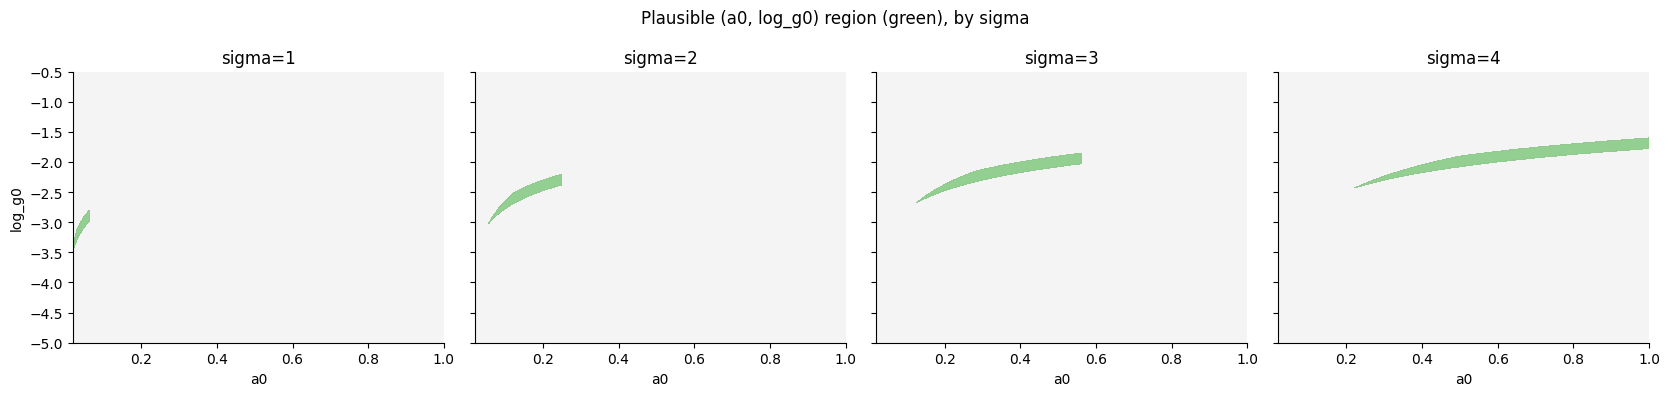

In [6]:
a_grid = np.linspace(0.02, 1.0, PLAUSIBLE_GRID_N)
log_g_grid = np.linspace(-5.0, -0.5, PLAUSIBLE_GRID_N)
A, LOG_G = np.meshgrid(a_grid, log_g_grid)

fig0, axes0 = plt.subplots(1, len(BASELINE_SIGMA_SLICES), figsize=(4.2 * len(BASELINE_SIGMA_SLICES), 4), sharey=True)
for ax, sig in zip(axes0, BASELINE_SIGMA_SLICES):
    G = 10.0 ** LOG_G
    Z_M, Z_H = sig / np.sqrt(A), A / G
    GAMMA = A * Z_H ** 2 / sig ** 2
    plausible = (
        (Z_M >= Z_M_RANGE[0]) & (Z_M <= Z_M_RANGE[1])
        & (Z_H >= Z_H_RANGE[0]) & (Z_H <= Z_H_RANGE[1])
        & (GAMMA >= GAMMA_MIN)
    )
    ax.contourf(A, LOG_G, plausible, levels=[-0.5, 0.5, 1.5], colors=["#eeeeee", "#4daf4a"], alpha=0.6)
    ax.set_title(f"sigma={sig}")
    ax.set_xlabel("a0")
    if sig == BASELINE_SIGMA_SLICES[0]:
        ax.set_ylabel("log_g0")
fig0.suptitle("Plausible (a0, log_g0) region (green), by sigma")
plt.tight_layout()
plt.show()

### Closed-form boundary

The plausible region is a diagonal band in `(a0, log_g0)`, not an
axis-aligned box, because `z_h = a/g` ties `log_g0` to `a0` directly.
Solving each inequality for the free variable gives the exact boundary:

- `z_m = sigma/sqrt(a)` in `Z_M_RANGE` => `a` in
  `[(sigma/Z_M_RANGE[1])**2, (sigma/Z_M_RANGE[0])**2]`.
- `z_h = a/g` in `Z_H_RANGE`, i.e. `log_g = log10(a/z_h)` =>
  `log_g0` in `[log10(a) - log10(Z_H_RANGE[1]), log10(a) - log10(Z_H_RANGE[0])]`
  -- a band whose center shifts with `a0`.

`tight_baseline_box` below uses this closed form to build a search box
that tightly wraps the plausible region, rather than bounding `(a0,
log_g0)` independently.

In [7]:
def a_bounds_from_zm(sigma, z_m_range):
    return (sigma / z_m_range[1]) ** 2, (sigma / z_m_range[0]) ** 2


def log_g_bounds_from_a_zh(a, z_h_range):
    return np.log10(a / z_h_range[1]), np.log10(a / z_h_range[0])


def tight_baseline_box(z_m_range, z_h_range, sigma_bounds=None, sigma_fixed=None):
    """
    A tight `(a_bounds, log_g_bounds)` outer search box that comfortably
    wraps the plausible region for either a fixed `sigma` or a `sigma`
    range, built from the same closed-form corner logic as
    `a_bounds_from_zm`/`log_g_bounds_from_a_zh` above.

    A generic wide box (e.g. `A_BOUNDS`/`LOG_G_BOUNDS`) can be much larger
    than the plausible region once `Z_M_RANGE`/`Z_H_RANGE` are narrowed, so
    `differential_evolution`'s randomly sampled population can end up
    containing zero plausible points -- every evaluation returns `inf`, and
    the optimizer converges to a meaningless result. Searching this tight
    box instead keeps the plausible region a large fraction of what's
    actually searched.
    """
    if sigma_fixed is not None:
        a_lo, a_hi = a_bounds_from_zm(sigma_fixed, z_m_range)
    else:
        sig_lo, sig_hi = sigma_bounds
        a_lo = a_bounds_from_zm(sig_lo, z_m_range)[0]
        a_hi = a_bounds_from_zm(sig_hi, z_m_range)[1]
    log_g_lo = log_g_bounds_from_a_zh(a_lo, z_h_range)[0]
    log_g_hi = log_g_bounds_from_a_zh(a_hi, z_h_range)[1]
    return (a_lo, a_hi), (log_g_lo, log_g_hi)

### How does the actual fit loss behave across the plausible region?

`loss_grid_baseline` evaluates the same MLE objective (`_weighted_neg_log_lik`)
that `fit_single_phase` minimizes, at every grid point directly, restricted
to each `sigma`'s plausible `(a0, log_g0)` band plus a small margin for
context. Swept across `SIGMA_LOSS_SWEEP` so the sweep covers wherever
Step 1's constrained fit ends up landing.

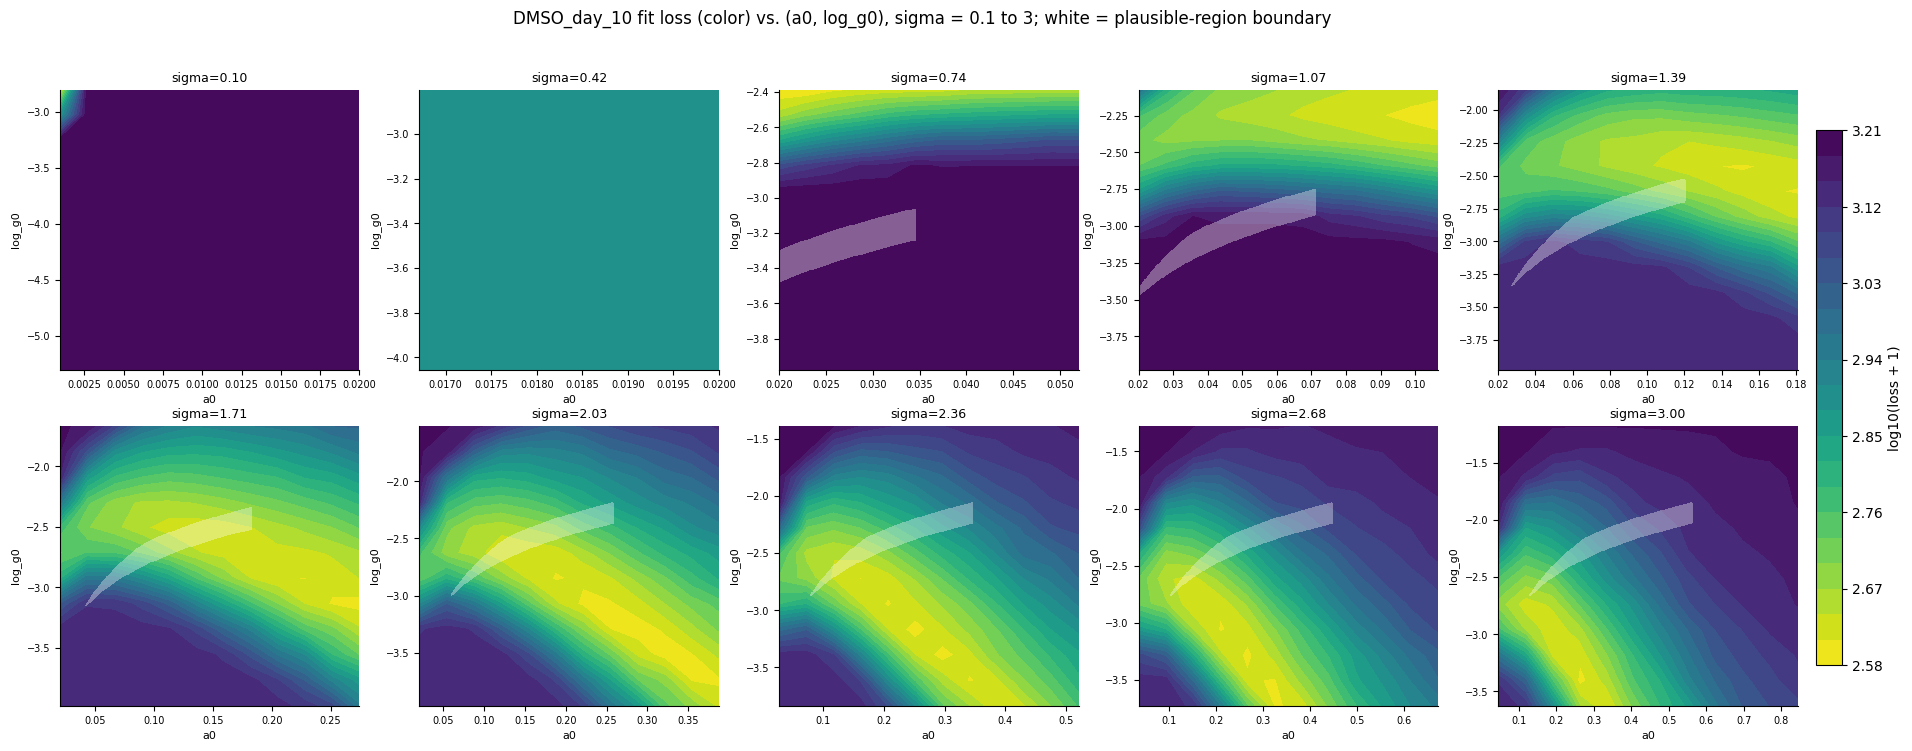

In [8]:
def loss_grid_baseline(cond, a_vals, log_g_vals, sigma, dt=0.1, n_paths=800, seed=0):
    noise = _make_common_noise(n_paths, dt, cond["t_max"], seed=seed)
    loss = np.full((len(log_g_vals), len(a_vals)), np.nan)
    for i, log_g in enumerate(log_g_vals):
        for j, a in enumerate(a_vals):
            g = 10.0 ** log_g
            z_h = a / g
            try:
                T, _, _ = simulate_fpt_and_state(
                    n_paths, a, g, sigma ** 2, z_h, z0=0.0, dt=dt, t_max=cond["t_max"], noise=noise,
                )
                loss[i, j] = _weighted_neg_log_lik(T, cond, n_paths)
            except (FloatingPointError, ValueError):
                loss[i, j] = np.nan
    return loss


def dmso_axis_ranges(sig):
    """(a_range, log_g_range) covered by the DMSO loss landscape at one
    sigma -- shared by both the coarse loss grid and the fine plausibility
    boundary below, so the two always agree on what region is being shown."""
    a_lo, a_hi = a_bounds_from_zm(sig, Z_M_RANGE)
    a_range = (max(a_lo * 0.5, 0.02), a_hi * 1.5)
    a_probe = np.linspace(*a_range, N_LOSS_GRID)
    log_g_lo = min(log_g_bounds_from_a_zh(a, Z_H_RANGE)[0] for a in a_probe) - LOSS_MARGIN
    log_g_hi = max(log_g_bounds_from_a_zh(a, Z_H_RANGE)[1] for a in a_probe) + LOSS_MARGIN
    return a_range, (log_g_lo, log_g_hi)


def dmso_loss_grid_at_sigma(sig):
    """(A_L, LOG_G_L, loss) for the DMSO loss landscape at one sigma --
    shared by both the sweep plot and Step 1's own-fit plot."""
    a_range, log_g_range = dmso_axis_ranges(sig)
    a_vals = np.linspace(*a_range, N_LOSS_GRID)
    log_g_vals = np.linspace(*log_g_range, N_LOSS_GRID)
    loss = loss_grid_baseline(dmso_curve, a_vals, log_g_vals, sig, seed=int(round(sig * 1000)))
    A_L, LOG_G_L = np.meshgrid(a_vals, log_g_vals)
    return A_L, LOG_G_L, loss


def fine_baseline_boundary(sig, a_range, log_g_range, n=N_BOUNDARY_GRID):
    """Traces the (a0, log_g0) plausibility boundary at a finer resolution
    than the (expensive, simulation-based) loss grid, since the
    plausibility check itself is pure algebra."""
    a_fine = np.linspace(*a_range, n)
    log_g_fine = np.linspace(*log_g_range, n)
    A_FINE, LOG_G_FINE = np.meshgrid(a_fine, log_g_fine)
    G_FINE = 10.0 ** LOG_G_FINE
    Z_M_FINE, Z_H_FINE = sig / np.sqrt(A_FINE), A_FINE / G_FINE
    GAMMA_FINE = A_FINE * Z_H_FINE ** 2 / sig ** 2
    mask = (
        (Z_M_FINE >= Z_M_RANGE[0]) & (Z_M_FINE <= Z_M_RANGE[1])
        & (Z_H_FINE >= Z_H_RANGE[0]) & (Z_H_FINE <= Z_H_RANGE[1]) & (GAMMA_FINE >= GAMMA_MIN)
    )
    return A_FINE, LOG_G_FINE, mask


def draw_plausible_region(ax, A, G, mask):
    """
    Shade the plausible region with a single translucent `contourf` fill
    (alpha=0.35), rather than an outline-only `contour(levels=[0.5])` --
    the plausible region here is normally many grid cells wide, so
    `contourf`'s polygons render fine.
    """
    if not mask.any():
        return
    ax.contourf(A, G, mask, levels=[0.5, 1.5], colors=["white"], alpha=0.35)


fig0e, axes0e = plt.subplots(2, 5, figsize=(4.6 * 5, 4.0 * 2), sharey=False)
for ax, sig in zip(axes0e.ravel(), SIGMA_LOSS_SWEEP):
    A_L, LOG_G_L, loss = dmso_loss_grid_at_sigma(sig)
    a_range, log_g_range = dmso_axis_ranges(sig)
    A_B, LOG_G_B, plausible_fine = fine_baseline_boundary(sig, a_range, log_g_range)
    cf = ax.contourf(A_L, LOG_G_L, np.log10(loss + 1.0), levels=20, cmap="viridis_r")
    draw_plausible_region(ax, A_B, LOG_G_B, plausible_fine)
    ax.set_title(f"sigma={sig:.2f}", fontsize=9)
    ax.set_xlabel("a0", fontsize=8)
    ax.set_ylabel("log_g0", fontsize=8)
    ax.tick_params(labelsize=7)
fig0e.colorbar(cf, ax=axes0e, fraction=0.015, pad=0.01, label="log10(loss + 1)")
fig0e.suptitle(f"DMSO_day_10 fit loss (color) vs. (a0, log_g0), sigma = "
               f"{SIGMA_LOSS_SWEEP[0]:.2g} to {SIGMA_LOSS_SWEEP[-1]:.2g}; white = plausible-region boundary")
plt.show()

### Boundary-hugging diagnostic

A fitted value sitting within 2% of its bound means the *box*, not the
data, decided that parameter. `_fmt` below flags this explicitly next to
every reported value.

In [9]:
def _fmt(name, value, bounds):
    lo, hi = bounds
    tol = 0.02 * (hi - lo)
    flag = ""
    if value - lo < tol:
        flag = "  <-- AT LOWER BOUND, widen it"
    elif hi - value < tol:
        flag = "  <-- AT UPPER BOUND, widen it"
    print(f"  {name:<15} = {value:.4f}   [bounds {bounds}]{flag}")

## Step 1 -- `(a0, log_g0, sigma)` from `DMSO_day_10` alone

`is_plausible_baseline` (Step 0) is passed in as a hard constraint
(`plausible_fn`): any `(a, log_g, sigma)` outside the biologically
plausible region is rejected outright, before its simulated loss is even
computed. The search runs in `tight_baseline_box(Z_M_RANGE, Z_H_RANGE,
sigma_bounds=SIGMA_BOUNDS)`, not the raw `A_BOUNDS`/`LOG_G_BOUNDS`.

In [10]:
A_BOUNDS_TIGHT, LOG_G_BOUNDS_TIGHT = tight_baseline_box(Z_M_RANGE, Z_H_RANGE, sigma_bounds=SIGMA_BOUNDS)
print(f"Step 1 search box: a0 in {tuple(round(x, 4) for x in A_BOUNDS_TIGHT)}, "
      f"log_g0 in {tuple(round(x, 4) for x in LOG_G_BOUNDS_TIGHT)}  "
      f"(outer envelope was a0 in {A_BOUNDS}, log_g0 in {LOG_G_BOUNDS})")

fit_dmso = fit_single_phase(
    dmso_curve, A_BOUNDS_TIGHT, LOG_G_BOUNDS_TIGHT, sigma_bounds=SIGMA_BOUNDS, seed=42,
    plausible_fn=is_plausible_baseline,
)
a0, log_g0, sigma = fit_dmso["a"], fit_dmso["log_g"], fit_dmso["sigma"]

print(f"DMSO_day_10 (n={dmso_curve['n_total']} worms), constrained to the plausible region:")
_fmt("a0", a0, A_BOUNDS_TIGHT)
_fmt("log_g0", log_g0, LOG_G_BOUNDS_TIGHT)
_fmt("sigma", sigma, SIGMA_BOUNDS)
print(f"  z_m0={sigma / np.sqrt(a0):.2f}  z_h0={a0 / (10.0 ** log_g0):.2f}  "
      f"plausible={is_plausible_baseline(a0, log_g0, sigma)}")
print(f"  loss   = {fit_dmso['loss']:.4f}")

Step 1 search box: a0 in (0.0004, 0.25), log_g0 in (np.float64(-5.1761), np.float64(-2.2041))  (outer envelope was a0 in (0.02, 1.0), log_g0 in (-5.0, -0.5))


DMSO_day_10 (n=232 worms), constrained to the plausible region:
  a0              = 0.1553   [bounds (0.0004, 0.25)]
  log_g0          = -2.5439   [bounds (np.float64(-5.176091259055681), np.float64(-2.2041199826559246))]
  sigma           = 1.5941   [bounds (0.2, 2.0)]
  z_m0=4.05  z_h0=54.34  plausible=True
  loss   = 398.9054


### Where does this fit actually land on the loss landscape?

Same construction as the `sigma`-sweep above, evaluated at Step 1's own
fitted `sigma`, with the optimizer's chosen `(a0, log_g0)` marked
directly.

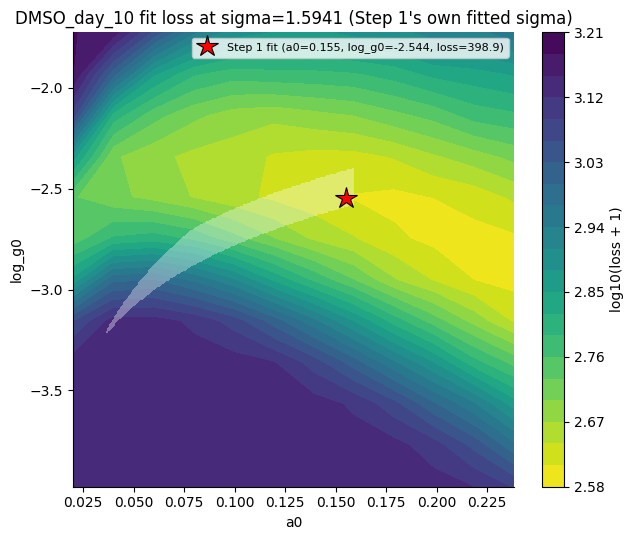

In [11]:
A_FIT, LOG_G_FIT, loss_fit = dmso_loss_grid_at_sigma(sigma)
a_range_fit, log_g_range_fit = dmso_axis_ranges(sigma)
A_FIT_B, LOG_G_FIT_B, plausible_fit = fine_baseline_boundary(sigma, a_range_fit, log_g_range_fit)

fig1a, ax1a = plt.subplots(figsize=(6.5, 5.5))
cf1a = ax1a.contourf(A_FIT, LOG_G_FIT, np.log10(loss_fit + 1.0), levels=20, cmap="viridis_r")
draw_plausible_region(ax1a, A_FIT_B, LOG_G_FIT_B, plausible_fit)
ax1a.plot(a0, log_g0, "r*", ms=16, mec="black", mew=0.8,
          label=f"Step 1 fit (a0={a0:.3f}, log_g0={log_g0:.3f}, loss={fit_dmso['loss']:.1f})")
ax1a.set_xlabel("a0")
ax1a.set_ylabel("log_g0")
ax1a.set_title(f"DMSO_day_10 fit loss at sigma={sigma:.4f} (Step 1's own fitted sigma)")
ax1a.legend(fontsize=8, loc="upper right")
fig1a.colorbar(cf1a, ax=ax1a, label="log10(loss + 1)")
plt.tight_layout()
plt.show()

## Step 1b -- `Auxin_day_10`'s own `(a0_auxin10, log_g0_auxin10)`

Independent single-phase fit, `sigma` fixed at Step 1's value, `(a, log_g)`
free -- **not** anchored to DMSO's dynamics. Same hard constraint as Step
1, and same tight-box treatment (`sigma` is fixed here, so
`tight_baseline_box` uses its `sigma_fixed=` path).

**This is also Auxin_day_21's post-switch phase.** No separate fit is done
for Auxin_day_21 -- see the module markdown at the top of this notebook.

In [12]:
A_BOUNDS_AUXIN10, LOG_G_BOUNDS_AUXIN10 = tight_baseline_box(Z_M_RANGE, Z_H_RANGE, sigma_fixed=sigma)

fit_auxin10 = fit_single_phase(
    auxin10_curve, A_BOUNDS_AUXIN10, LOG_G_BOUNDS_AUXIN10, sigma_fixed=sigma, seed=43,
    plausible_fn=is_plausible_baseline,
)
a0_auxin10, log_g0_auxin10 = fit_auxin10["a"], fit_auxin10["log_g"]

print(f"Auxin_day_10 (n={auxin10_curve['n_total']} worms), sigma fixed at {sigma:.4f}, constrained:")
_fmt("a0_auxin10", a0_auxin10, A_BOUNDS_AUXIN10)
_fmt("log_g0_auxin10", log_g0_auxin10, LOG_G_BOUNDS_AUXIN10)
print(f"  loss = {fit_auxin10['loss']:.4f}")

Auxin_day_10 (n=81 worms), sigma fixed at 1.5941, constrained:
  a0_auxin10      = 0.1035   [bounds (np.float64(0.025412186510295722), np.float64(0.15882616568934824))]
  log_g0_auxin10  = -2.7358   [bounds (np.float64(-3.3731092162461946), np.float64(-2.4011379398464383))]
  loss = 186.9954


## Auxin_day_21 -- constructed, not fit

Auxin_day_21 worms follow the DMSO baseline `(a0, g0)` up to day 21, then
switch to Auxin_day_10's own fitted `(a0_auxin10, g0_auxin10)` from Step
1b, directly -- no separate optimization step. `a1, g1` below are exactly
`a0_auxin10, g0_auxin10`.

In [13]:
a1, g1 = a0_auxin10, 10.0 ** log_g0_auxin10
print(f"Auxin_day_21 post-switch dynamics (= Auxin_day_10's own fit): a1={a1:.4f}, g1={g1:.4e}")

Auxin_day_21 post-switch dynamics (= Auxin_day_10's own fit): a1=0.1035, g1=1.8376e-03


### Sanity-checking `_weighted_neg_log_lik` against the actual fits

Evaluated at each condition's already-fitted parameters, using enough
paths to be reasonably stable (`n_paths_final`-scale), just to confirm the
function runs end-to-end and returns finite, sensible numbers -- not used
to refit anything here.

In [14]:
g0_check = 10.0 ** log_g0
noise_dmso_check = _make_common_noise(3000, 0.1, dmso_curve["t_max"], seed=7)
T_dmso_check, _, _ = simulate_fpt_and_state(
    3000, a0, g0_check, sigma ** 2, a0 / g0_check, z0=0.0, dt=0.1,
    t_max=dmso_curve["t_max"], noise=noise_dmso_check,
)
nll_dmso_check = _weighted_neg_log_lik(T_dmso_check, dmso_curve, 3000)
loss_dmso_check = _weighted_log_loss(
    km_from_fpt(T_dmso_check, dmso_curve["t_emp"], t_max=dmso_curve["t_max"]),
    dmso_curve["S_emp"], dmso_curve["weight_emp"], 3000,
)
print(f"DMSO_day_10 at fitted (a0={a0:.4f}, log_g0={log_g0:.4f}, sigma={sigma:.4f}):")
print(f"  _weighted_neg_log_lik = {nll_dmso_check:.4f}   _weighted_log_loss = {loss_dmso_check:.4f}")

noise_auxin10_check = _make_common_noise(3000, 0.1, auxin10_curve["t_max"], seed=9)
T_auxin10_check, _, _ = simulate_fpt_and_state(
    3000, a0_auxin10, g1, sigma ** 2, a0_auxin10 / g1, z0=0.0, dt=0.1,
    t_max=auxin10_curve["t_max"], noise=noise_auxin10_check,
)
nll_auxin10_check = _weighted_neg_log_lik(T_auxin10_check, auxin10_curve, 3000)
loss_auxin10_check = _weighted_log_loss(
    km_from_fpt(T_auxin10_check, auxin10_curve["t_emp"], t_max=auxin10_curve["t_max"]),
    auxin10_curve["S_emp"], auxin10_curve["weight_emp"], 3000,
)
print(f"Auxin_day_10 at fitted (a0_auxin10={a0_auxin10:.4f}, log_g0_auxin10={log_g0_auxin10:.4f}):")
print(f"  _weighted_neg_log_lik = {nll_auxin10_check:.4f}   _weighted_log_loss = {loss_auxin10_check:.4f}")

DMSO_day_10 at fitted (a0=0.1553, log_g0=-2.5439, sigma=1.5941):
  _weighted_neg_log_lik = 407.1512   _weighted_log_loss = 266.9773
Auxin_day_10 at fitted (a0_auxin10=0.1035, log_g0_auxin10=-2.7358):
  _weighted_neg_log_lik = 197.8948   _weighted_log_loss = 47.9988


## Summary

In [15]:
print("Automatically fitted parameters for the switching Langevin model:")
print()
print("DMSO_day_10 (Step 1 -- single phase, free a0/log_g0/sigma):")
print(f"  a0       = {a0:.4f}")
print(f"  log_g0   = {log_g0:.4f}")
print(f"  sigma    = {sigma:.4f}")
print()
print("Auxin_day_10 (Step 1b -- single phase, sigma fixed at the DMSO fit):")
print(f"  a0_auxin10     = {a0_auxin10:.4f}")
print(f"  log_g0_auxin10 = {log_g0_auxin10:.4f}")
print()
print("Auxin_day_21 (constructed, not fit): DMSO baseline (a0, log_g0) up to")
print(f"  day {T_SWITCH_21:.0f}, then Auxin_day_10's own fitted (a0_auxin10, log_g0_auxin10) --")
print(f"  i.e. a1={a1:.4f}, g1={g1:.4e} above.")

Automatically fitted parameters for the switching Langevin model:

DMSO_day_10 (Step 1 -- single phase, free a0/log_g0/sigma):
  a0       = 0.1553
  log_g0   = -2.5439
  sigma    = 1.5941

Auxin_day_10 (Step 1b -- single phase, sigma fixed at the DMSO fit):
  a0_auxin10     = 0.1035
  log_g0_auxin10 = -2.7358

Auxin_day_21 (constructed, not fit): DMSO baseline (a0, log_g0) up to
  day 21, then Auxin_day_10's own fitted (a0_auxin10, log_g0_auxin10) --
  i.e. a1=0.1035, g1=1.8376e-03 above.
